# 00 Exploratory Data Analysis (EDA) - PPG-DaLiA Multimodal Dataset

**Đồ án**: Conditional PPG Waveform Generation with 1D cVAE (AI cho IoT)

**Mục tiêu EDA**:
1. **Khảo sát cấu trúc Dataset**: 15 đối tượng (S1..S15), thời lượng đo đạc, số lượng mẫu và tính toàn vẹn.
2. **Tín hiệu đa kênh đồng bộ**: Đối chiếu PPG cổ tay (64 Hz), ECG ngực (700 Hz), gia tốc 3 trục ACC (32 Hz) và nhịp tim chuẩn (HR reference).
3. **Hình thái sóng PPG (Morphology) & Bộ lọc**: Phân tích đỉnh tâm thu (systolic peak), khuyết dicrotic, tác dụng của bộ lọc dải thông Butterworth [0.5 - 8.0 Hz] và phổ tần số FFT.
4. **Phân bố nhịp tim (HR Distribution)**: Khảo sát phân bố HR toàn thể và từng đối tượng, phân nhóm theo các điều kiện sinh sóng 60 / 80 / 120 bpm.
5. **Tác động của nhiễu vận động (Motion Artifacts)**: Tương quan giữa độ lớn gia tốc cổ tay và biến dạng hình thái sóng PPG.
6. **Phân chia tập dữ liệu (Subject-Independent Cross-Validation)**: Kiểm tra phân bố Train / Val / Test theo fold tránh rò rỉ dữ liệu người dùng.

In [1]:
from pathlib import Path
import os, sys, platform, re, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, sosfiltfilt, welch
from scipy.fft import rfft, rfftfreq

# Tự động phát hiện DATA_ROOT trên Kaggle hoặc Local
input_dir = Path('/kaggle/input')
DATA_ROOT = None
if os.environ.get('PPGDALIA_ROOT'):
    p = Path(os.environ['PPGDALIA_ROOT'])
    if p.exists(): DATA_ROOT = p

if DATA_ROOT is None and input_dir.exists():
    for p in input_dir.rglob('*.pkl'):
        if re.search(r'(?<![A-Z0-9])S(1[0-5]|[1-9])(?![A-Z0-9])', p.stem.upper()):
            rel = p.relative_to(input_dir)
            DATA_ROOT = input_dir / rel.parts[0]
            print(f'Discovered DATA_ROOT: {DATA_ROOT}')
            break

if DATA_ROOT is None:
    _candidates = [Path('/kaggle/input/ppg-dalia-dataset'), Path('/kaggle/input/datasets'), Path('/kaggle/input/ppg-dalia')]
    DATA_ROOT = next((p for p in _candidates if p.exists() and p.is_dir()), _candidates[0])

# Cấu hình thư mục output lưu biểu đồ
OUTPUT_ROOT = Path('artifacts')
FIGURES_DIR = OUTPUT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Kết nối src code của repo
repo_candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / 'Final_IOT_for_AI']
repo_root = next((p for p in repo_candidates if (p / 'src').exists()), None)
if repo_root is None:
    raise FileNotFoundError('Could not locate src/ directory')
sys.path.insert(0, str(repo_root / 'src'))

from ppg_cvae.data.dalia import discover_subject_files, load_subject
from ppg_cvae.data.splits import get_fold
from ppg_cvae.data.preprocessing import filter_continuous

print({'DATA_ROOT': str(DATA_ROOT), 'FIGURES_DIR': str(FIGURES_DIR), 'repo_root': str(repo_root)})
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'DATA_ROOT does not exist: {DATA_ROOT}')

# Cấu hình hiển thị biểu đồ đẹp mắt
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.dpi'] = 120


Discovered DATA_ROOT: /kaggle/input/datasets
{'DATA_ROOT': '/kaggle/input/datasets', 'FIGURES_DIR': 'artifacts/figures', 'repo_root': '/kaggle/working/krun_project'}


In [2]:
# ==========================================================================
# PHẦN 1: KHẢO SÁT TỔNG QUAN 15 SUBJECTS (DATASET AUDIT)
# ==========================================================================
subject_files = discover_subject_files(DATA_ROOT)
print(f'Tìm thấy tổng cộng {len(subject_files)} subject files.')

summary_rows = []
all_records = {}

for p in subject_files:
    rec = load_subject(p)
    assert rec.subject_id not in all_records, f'Duplicate subject {rec.subject_id}'
    all_records[rec.subject_id] = rec
    ppg_len = len(rec.ppg)
    duration_hours = (ppg_len / rec.ppg_fs) / 3600.0
    hr_arr = rec.hr[np.isfinite(rec.hr)] if rec.hr is not None else np.array([])
    
    summary_rows.append({
        'Subject': rec.subject_id,
        'PPG Samples': ppg_len,
        'Duration (hours)': round(duration_hours, 2),
        'Sampling Rate (Hz)': rec.ppg_fs,
        'HR Count': len(hr_arr),
        'HR Min (bpm)': round(float(np.min(hr_arr)), 1) if len(hr_arr) else np.nan,
        'HR Mean (bpm)': round(float(np.mean(hr_arr)), 1) if len(hr_arr) else np.nan,
        'HR Max (bpm)': round(float(np.max(hr_arr)), 1) if len(hr_arr) else np.nan,
        'HR Std (bpm)': round(float(np.std(hr_arr)), 1) if len(hr_arr) else np.nan,
        'ECG Available': rec.ecg is not None,
        'ACC Available': rec.acc is not None
    })

assert set(all_records) == {f'S{i}' for i in range(1,16)}, 'Missing subjects'
df_summary = pd.DataFrame(summary_rows).sort_values('Subject', key=lambda col: col.str.replace('S','').astype(int))
print('\n=== BẢNG TỔNG HỢP 15 ĐỐI TƯỢNG PPG-DALIA ===')
print(df_summary.to_string(index=False))
df_summary.to_csv(FIGURES_DIR / 'dataset_summary.csv', index=False)

total_hours = df_summary['Duration (hours)'].sum()
print(f'\nTổng thời lượng dữ liệu toàn bộ dataset: {total_hours:.1f} giờ ghi liên tục.')


Tìm thấy tổng cộng 15 subject files.



=== BẢNG TỔNG HỢP 15 ĐỐI TƯỢNG PPG-DALIA ===
Subject  PPG Samples  Duration (hours)  Sampling Rate (Hz)  HR Count  HR Min (bpm)  HR Mean (bpm)  HR Max (bpm)  HR Std (bpm)  ECG Available  ACC Available
     S1       589568              2.56                64.0      4603          41.9           74.8         150.2          16.2           True           True
     S2       525120              2.28                64.0      4099          56.9           82.5         149.2          13.7           True           True
     S3       559424              2.43                64.0      4367          44.5           89.0         148.7          15.9           True           True
     S4       585600              2.54                64.0      4572          56.2           87.9         132.0          13.0           True           True
     S5       595520              2.58                64.0      4649          82.5          125.8         187.0          19.6           True           True
     S6       3360

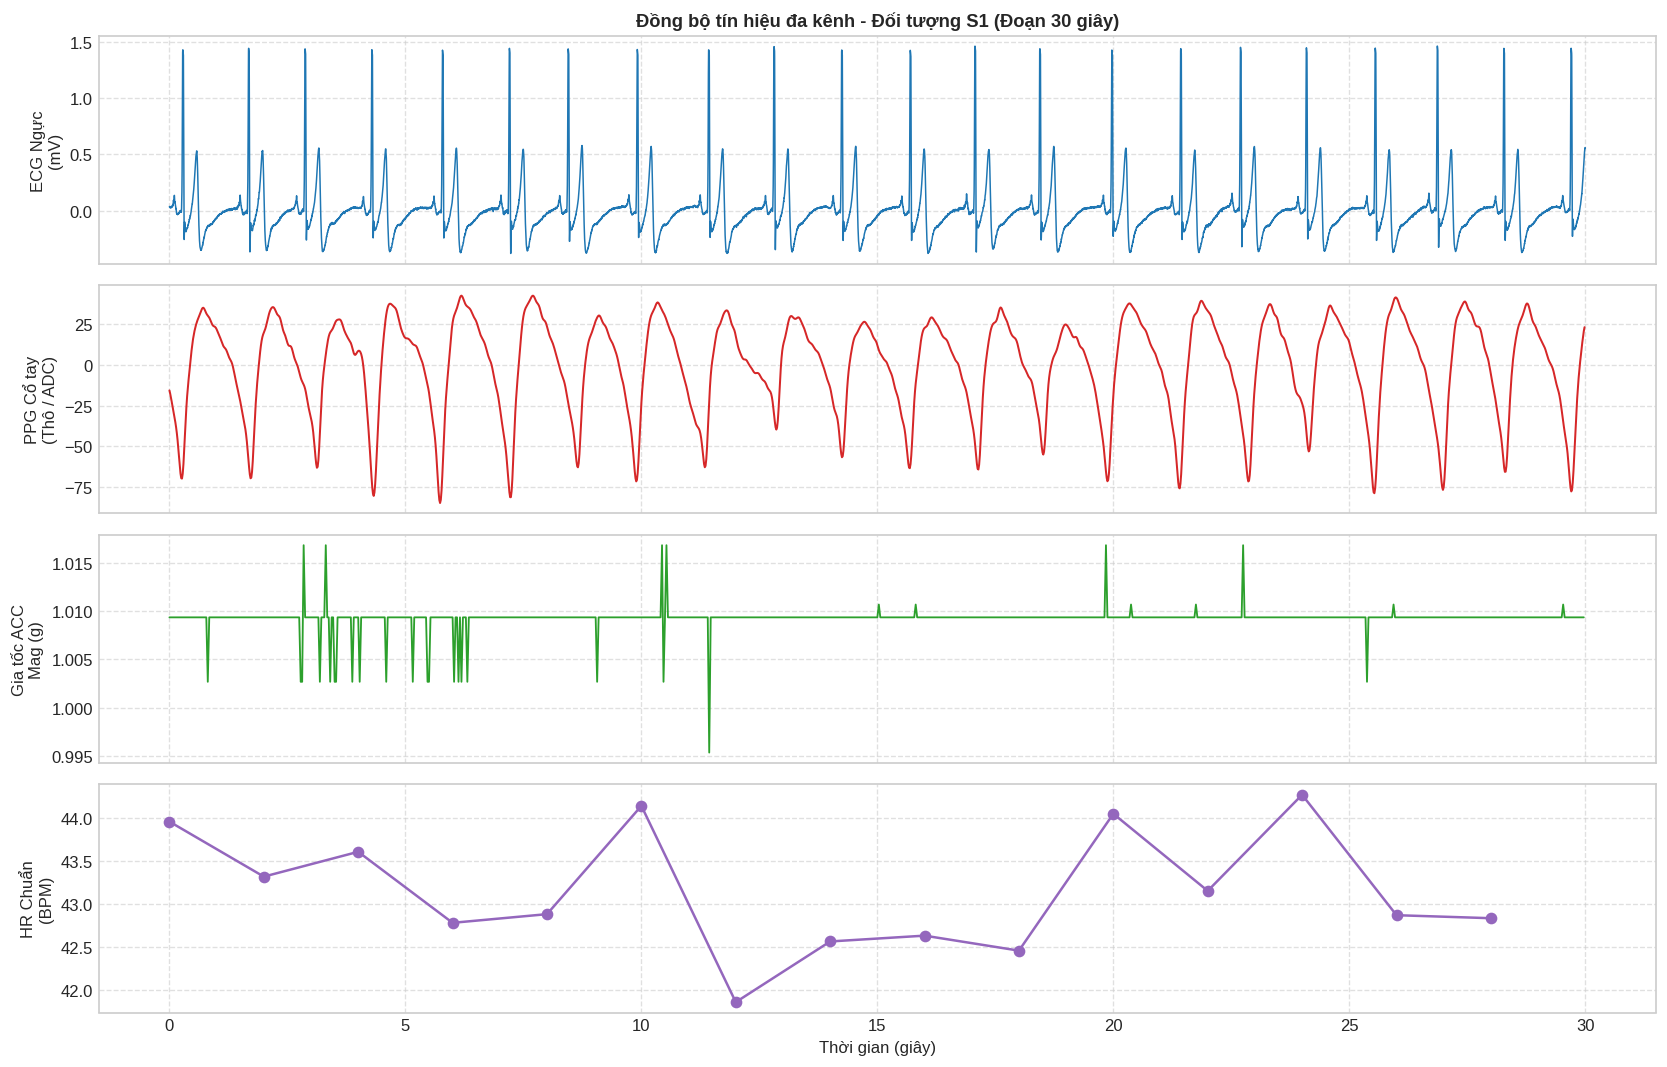

Đã lưu hình ảnh: artifacts/figures/eda_multimodal_alignment.png


In [3]:
# ==========================================================================
# PHẦN 2: CẤU TRÚC TÍN HIỆU ĐA KÊNH ĐỒNG BỘ (MULTIMODAL SIGNALS ALIGNMENT)
# ==========================================================================
# Chọn đối tượng S1 để phân tích đồng bộ
rec_s1 = all_records.get('S1', list(all_records.values())[0])
fs_ppg = rec_s1.ppg_fs

# Trích xuất đoạn 30 giây (từ giây thứ 100 đến 130)
start_sec = 120
duration_sec = 30
end_sec = start_sec + duration_sec

idx_ppg_start, idx_ppg_end = int(start_sec * fs_ppg), int(end_sec * fs_ppg)
time_ppg = np.arange(idx_ppg_end-idx_ppg_start)/fs_ppg
seg_ppg = rec_s1.ppg[idx_ppg_start:idx_ppg_end]

# Accelerometer (32 Hz)
fs_acc = 32.0
idx_acc_start, idx_acc_end = int(start_sec * fs_acc), int(end_sec * fs_acc)
time_acc = np.arange(idx_acc_end-idx_acc_start)/fs_acc
if rec_s1.acc is not None and len(rec_s1.acc) > idx_acc_end:
    seg_acc = rec_s1.acc[idx_acc_start:idx_acc_end]
    # Magnitude: sqrt(x^2 + y^2 + z^2)
    acc_mag = np.linalg.norm(seg_acc, axis=1) if seg_acc.ndim == 2 else seg_acc
else:
    acc_mag = np.full_like(time_acc,np.nan)

# ECG reference (700 Hz)
fs_ecg = 700.0
idx_ecg_start, idx_ecg_end = int(start_sec * fs_ecg), int(end_sec * fs_ecg)
time_ecg = np.arange(idx_ecg_end-idx_ecg_start)/fs_ecg
seg_ecg = rec_s1.ecg[idx_ecg_start:idx_ecg_end] if rec_s1.ecg is not None else np.full_like(time_ecg,np.nan)

# Vẽ biểu đồ đồng bộ 4 kênh
fig, axs = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

axs[0].plot(time_ecg, seg_ecg, color='#1f77b4', lw=0.9)
axs[0].set_ylabel('ECG Ngực\n(mV)')
axs[0].set_title(f'Đồng bộ tín hiệu đa kênh - Đối tượng {rec_s1.subject_id} (Đoạn 30 giây)', fontweight='bold')

axs[1].plot(time_ppg, seg_ppg, color='#d62728', lw=1.2)
axs[1].set_ylabel('PPG Cổ tay\n(Thô / ADC)')

axs[2].plot(time_acc, acc_mag, color='#2ca02c', lw=1.1)
axs[2].set_ylabel('Gia tốc ACC\nMag (g)')

# Heart Rate track (mỗi 2s có 1 mẫu HR)
# Exploratory view only: s0=0 assumption; verify in step 01 before training.
hr_centers = 4 + 2*np.arange(len(rec_s1.hr)) if rec_s1.hr is not None else np.array([])
hr_mask = (hr_centers >= start_sec) & (hr_centers < end_sec)
hr_slice = rec_s1.hr[hr_mask] if rec_s1.hr is not None else []
time_hr = hr_centers[hr_mask] - start_sec
axs[3].plot(time_hr, hr_slice, color='#9467bd', marker='o', lw=1.5)
axs[3].set_ylabel('HR Chuẩn\n(BPM)')
axs[3].set_xlabel('Thời gian (giây)')

for ax in axs: ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
fig_path = FIGURES_DIR / 'eda_multimodal_alignment.png'
plt.savefig(fig_path, dpi=200)
plt.show()
print(f'Đã lưu hình ảnh: {fig_path}')


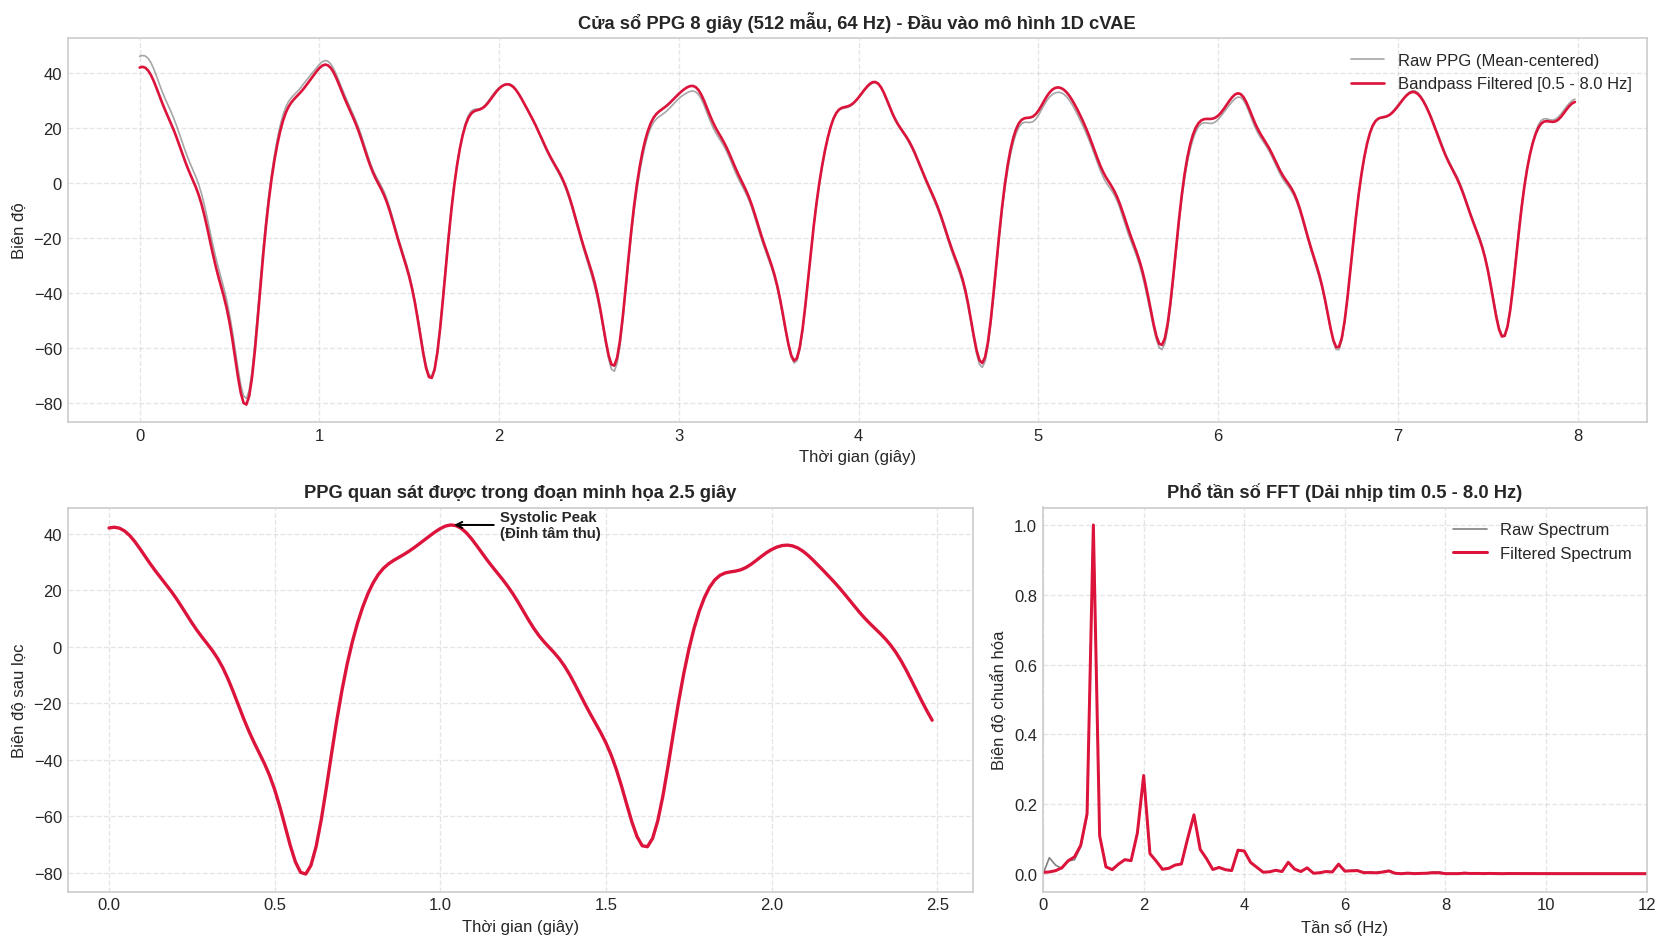

Đã lưu hình ảnh: artifacts/figures/eda_ppg_morphology_and_spectrum.png


In [4]:
# ==========================================================================
# PHẦN 3: HÌNH THÁI SÓNG PPG (MORPHOLOGY) & BỘ LỌC BANDPASS [0.5 - 8.0 Hz]
# ==========================================================================
# Lấy 1 cửa sổ chuẩn 8 giây (512 mẫu ở 64Hz) - Kích thước đầu vào của 1D cVAE
win_len = 512
idx_win_start = int(200 * fs_ppg)
idx_win_end = idx_win_start + win_len
t_win = np.arange(win_len) / fs_ppg

raw_window = rec_s1.ppg[idx_win_start:idx_win_end]
# Lọc liên tục trên đoạn dài rồi cắt (tránh edge artifact của bộ lọc)
filtered_ppg = filter_continuous(rec_s1.ppg)
filtered_window = filtered_ppg[idx_win_start:idx_win_end]

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1.2, 0.8])

# 1. Toàn bộ cửa sổ 8s (512 mẫu)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_win, raw_window - np.mean(raw_window), label='Raw PPG (Mean-centered)', color='gray', alpha=0.7, lw=1.0)
ax1.plot(t_win, filtered_window, label='Bandpass Filtered [0.5 - 8.0 Hz]', color='crimson', lw=1.6)
ax1.set_title('Cửa sổ PPG 8 giây (512 mẫu, 64 Hz) - Đầu vào mô hình 1D cVAE', fontweight='bold')
ax1.set_xlabel('Thời gian (giây)')
ax1.set_ylabel('Biên độ')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Zoom chi tiết 2 chu kỳ đập tim (2.5 giây)
ax2 = fig.add_subplot(gs[1, 0])
zoom_samples = int(2.5 * fs_ppg)
t_zoom = t_win[:zoom_samples]
ax2.plot(t_zoom, filtered_window[:zoom_samples], color='crimson', lw=2.0)
ax2.set_title('PPG quan sát được trong đoạn minh họa 2.5 giây', fontweight='bold')
ax2.set_xlabel('Thời gian (giây)')
ax2.set_ylabel('Biên độ sau lọc')

# Đánh dấu các mốc giải phẫu quan trọng trên sóng
peaks_idx = [np.argmax(filtered_window[:zoom_samples//2])]
if len(peaks_idx):
    p0 = peaks_idx[0]
    ax2.annotate('Systolic Peak\n(Đỉnh tâm thu)', xy=(t_zoom[p0], filtered_window[p0]),
                 xytext=(t_zoom[p0] + 0.15, filtered_window[p0] * 0.9),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                 fontsize=9, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

# 3. Phổ biên độ tần số (FFT Amplitude Spectrum)
ax3 = fig.add_subplot(gs[1, 1])
freqs = rfftfreq(win_len, 1.0 / fs_ppg)
fft_raw = np.abs(rfft(raw_window - np.mean(raw_window)))
fft_filt = np.abs(rfft(filtered_window))

ax3.plot(freqs, fft_raw / np.max(fft_raw), label='Raw Spectrum', color='gray', lw=1.0)
ax3.plot(freqs, fft_filt / np.max(fft_filt), label='Filtered Spectrum', color='crimson', lw=1.8)
ax3.set_xlim(0, 12)
ax3.set_title('Phổ tần số FFT (Dải nhịp tim 0.5 - 8.0 Hz)', fontweight='bold')
ax3.set_xlabel('Tần số (Hz)')
ax3.set_ylabel('Biên độ chuẩn hóa')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig_path = FIGURES_DIR / 'eda_ppg_morphology_and_spectrum.png'
plt.savefig(fig_path, dpi=200)
plt.show()
print(f'Đã lưu hình ảnh: {fig_path}')


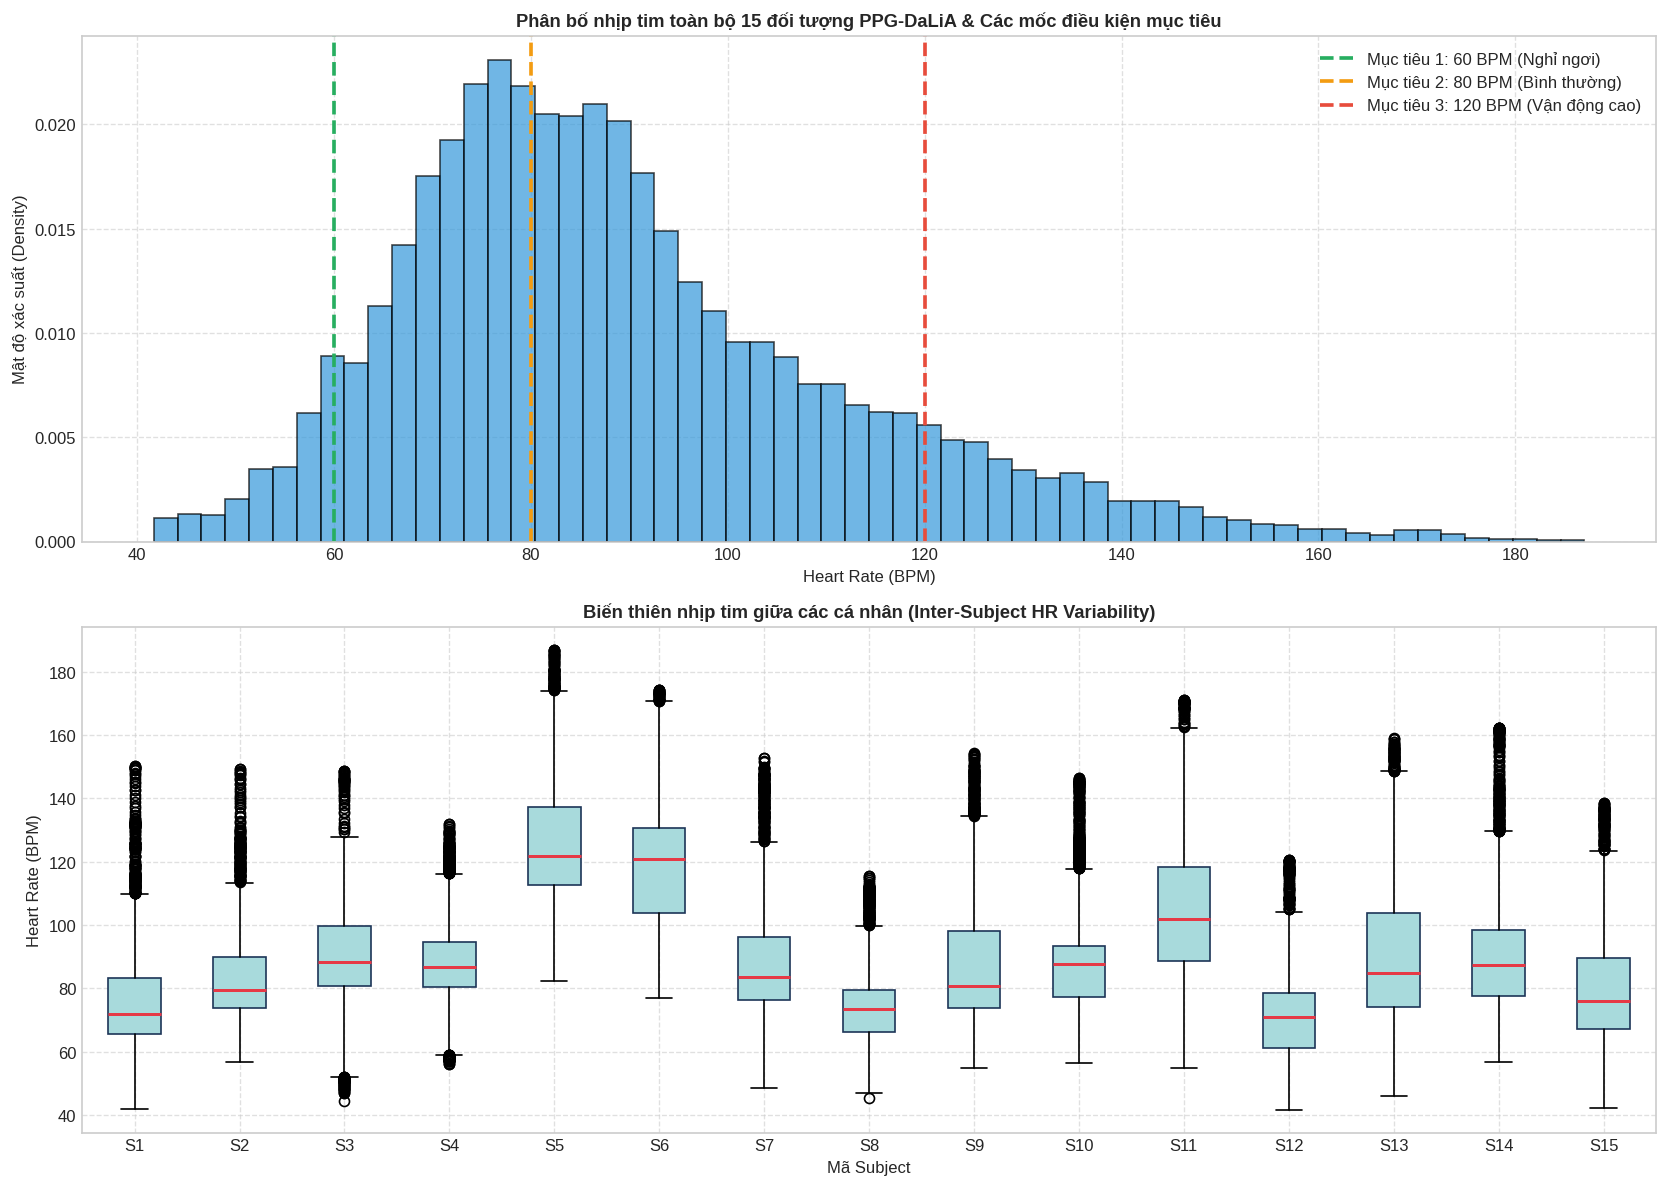

Thống kê phân nhóm dữ liệu:
- Khoảng nhịp chậm (< 70 bpm - ứng với điều kiện 60 bpm): 17.9%
- Khoảng nhịp trung bình (70 - 95 bpm - ứng với điều kiện 80 bpm): 50.0%
- Khoảng nhịp nhanh (> 95 bpm - ứng với điều kiện 120 bpm): 32.1%


In [5]:
# ==========================================================================
# PHẦN 4: PHÂN BỐ NHỊP TIM (HEART RATE DISTRIBUTION) & CÁC MỨC ĐIỀU KIỆN
# ==========================================================================
# Tổng hợp toàn bộ mảng HR của 15 đối tượng
all_hr_list = []
hr_by_subject = []
subject_names = []

for sid in df_summary['Subject']:
    rec = all_records[sid]
    if rec.hr is not None:
        valid_hr = rec.hr[np.isfinite(rec.hr)]
        all_hr_list.extend(valid_hr)
        hr_by_subject.append(valid_hr)
        subject_names.append(sid)

all_hr = np.array(all_hr_list)

fig, axs = plt.subplots(2, 1, figsize=(14, 10))

# 1. Histogram tổng thể và các mốc điều kiện cVAE (60, 80, 120 bpm)
axs[0].hist(all_hr, bins=60, color='#3498db', edgecolor='black', alpha=0.7, density=True)
axs[0].set_title('Phân bố nhịp tim toàn bộ 15 đối tượng PPG-DaLiA & Các mốc điều kiện mục tiêu', fontweight='bold')
axs[0].set_xlabel('Heart Rate (BPM)')
axs[0].set_ylabel('Mật độ xác suất (Density)')

# Vẽ 3 đường thẳng đại diện cho 3 điều kiện HR: 60, 80, 120 bpm
target_hrs = [60, 80, 120]
colors = ['#27ae60', '#f39c12', '#e74c3c']
labels = ['Mục tiêu 1: 60 BPM (Nghỉ ngơi)', 'Mục tiêu 2: 80 BPM (Bình thường)', 'Mục tiêu 3: 120 BPM (Vận động cao)']
for thr, c, lbl in zip(target_hrs, colors, labels):
    axs[0].axvline(thr, color=c, linestyle='--', lw=2.2, label=lbl)
axs[0].legend(fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.6)

# 2. Boxplot phân bố HR theo từng Subject
axs[1].boxplot(hr_by_subject, tick_labels=subject_names, patch_artist=True,
               boxprops=dict(facecolor='#a8dadc', color='#1d3557'),
               medianprops=dict(color='#e63946', lw=1.8))
axs[1].set_title('Biến thiên nhịp tim giữa các cá nhân (Inter-Subject HR Variability)', fontweight='bold')
axs[1].set_xlabel('Mã Subject')
axs[1].set_ylabel('Heart Rate (BPM)')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig_path = FIGURES_DIR / 'eda_hr_distribution.png'
plt.savefig(fig_path, dpi=200)
plt.show()

# Thống kê tỷ lệ phần trăm mẫu trong các khoảng nhịp tim
pct_low = np.mean(all_hr < 70) * 100
pct_normal = np.mean((all_hr >= 70) & (all_hr <= 95)) * 100
pct_high = np.mean(all_hr > 95) * 100

print(f'Thống kê phân nhóm dữ liệu:')
print(f'- Khoảng nhịp chậm (< 70 bpm - ứng với điều kiện 60 bpm): {pct_low:.1f}%')
print(f'- Khoảng nhịp trung bình (70 - 95 bpm - ứng với điều kiện 80 bpm): {pct_normal:.1f}%')
print(f'- Khoảng nhịp nhanh (> 95 bpm - ứng với điều kiện 120 bpm): {pct_high:.1f}%')


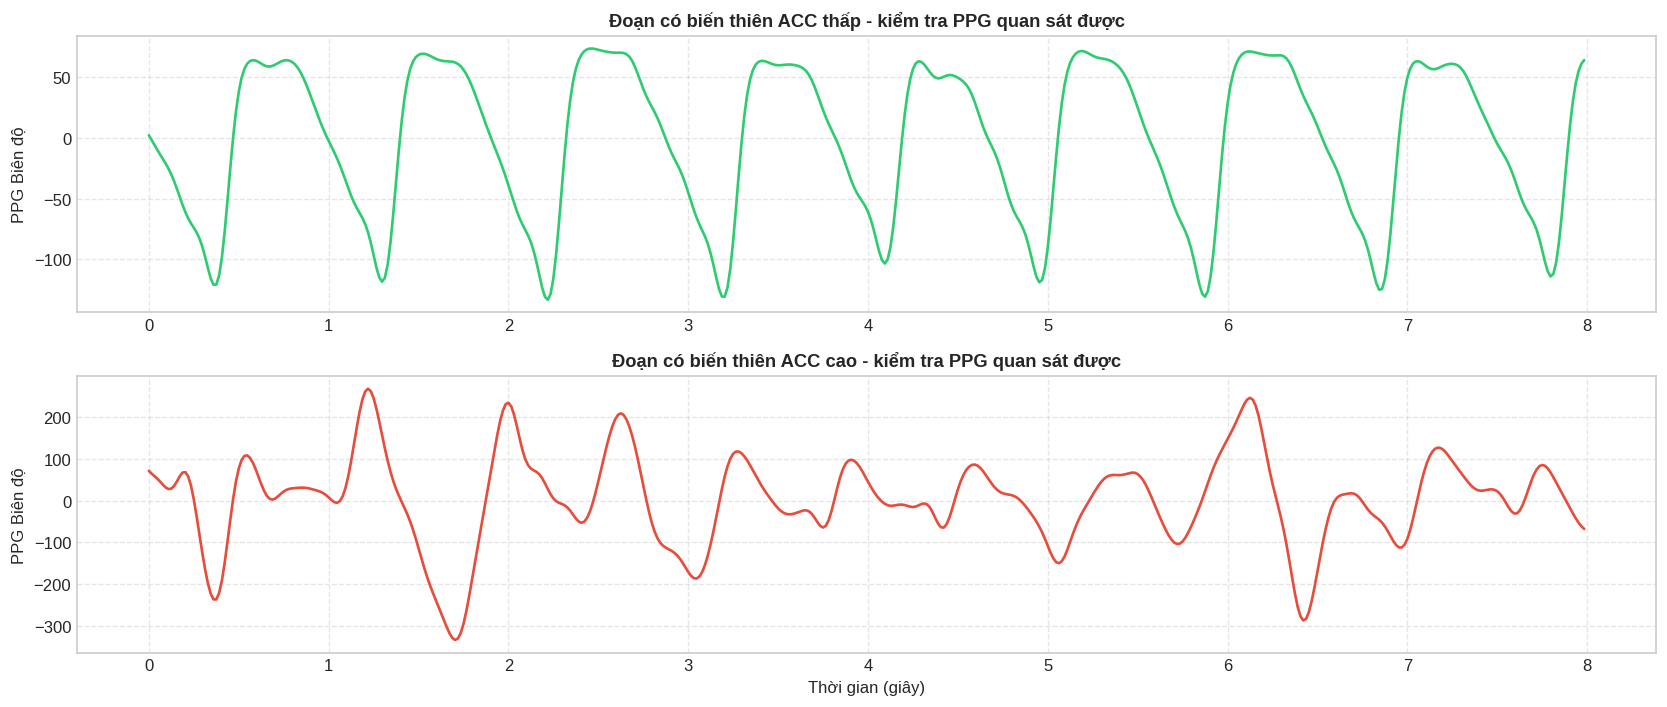

Đã lưu hình ảnh: artifacts/figures/eda_motion_artifact_comparison.png


In [6]:
# ==========================================================================
# PHẦN 5: TÁC ĐỘNG CỦA NHIỄU VẬN ĐỘNG (MOTION ARTIFACTS)
# ==========================================================================
# So sánh đoạn tĩnh (ngồi làm việc) vs đoạn vận động (leo cầu thang/đạp xe)
# Tìm đoạn gia tốc ACC thấp và đoạn ACC cao trong Subject S1
fs_acc = 32.0
acc_full = rec_s1.acc
if acc_full is not None and acc_full.ndim == 2:
    acc_mag_full = np.linalg.norm(acc_full, axis=1)
    # Tính rolling mean độ lớn gia tốc mỗi 4 giây (128 mẫu)
    step = 128
    acc_energies = [np.std(acc_mag_full[i:i+256]) for i in range(0, len(acc_mag_full)-256+1, step)]
    
    # Đoạn tĩnh nhất (min std) và đoạn động nhất (max std)
    quiet_idx = np.argmin(acc_energies) * step
    active_idx = np.argmax(acc_energies) * step
    
    quiet_time = quiet_idx / fs_acc
    active_time = active_idx / fs_acc
    
    # Trích xuất 8 giây tương ứng cho PPG (64 Hz)
    q_ppg_start = int(quiet_time * fs_ppg)
    a_ppg_start = int(active_time * fs_ppg)
    
    quiet_ppg = filtered_ppg[q_ppg_start:q_ppg_start + 512]
    active_ppg = filtered_ppg[a_ppg_start:a_ppg_start + 512]
    
    t_8s = np.arange(512) / fs_ppg
    
    fig, axs = plt.subplots(2, 1, figsize=(14, 6))
    
    axs[0].plot(t_8s, quiet_ppg, color='#2ecc71', lw=1.6)
    axs[0].set_title('Đoạn có biến thiên ACC thấp - kiểm tra PPG quan sát được', fontweight='bold')
    axs[0].set_ylabel('PPG Biên độ')
    axs[0].grid(True, linestyle='--', alpha=0.5)
    
    axs[1].plot(t_8s, active_ppg, color='#e74c3c', lw=1.6)
    axs[1].set_title('Đoạn có biến thiên ACC cao - kiểm tra PPG quan sát được', fontweight='bold')
    axs[1].set_xlabel('Thời gian (giây)')
    axs[1].set_ylabel('PPG Biên độ')
    axs[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    fig_path = FIGURES_DIR / 'eda_motion_artifact_comparison.png'
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print(f'Đã lưu hình ảnh: {fig_path}')
else:
    print('Không có kênh ACC để phân tích nhiễu động.')


In [7]:
# ==========================================================================
# PHẦN 6: PHÂN CHIA FOLD CROSS-VALIDATION (SUBJECT-INDEPENDENT SPLITS)
# ==========================================================================
fold_1 = get_fold(fold_id=1)
print('=== KIỂM TOÁN PHÂN CHIA FOLD 1 (SUBJECT-INDEPENDENT) ===')
print('Train Subjects (9 người):', sorted(list(fold_1.train_subjects), key=lambda s: int(s.replace('S',''))))
print('Validation Subjects (3 người):', sorted(list(fold_1.val_subjects), key=lambda s: int(s.replace('S',''))))
print('Test Subjects (3 người):', sorted(list(fold_1.test_subjects), key=lambda s: int(s.replace('S',''))))

# Kiểm tra rò rỉ dữ liệu
overlap_train_val = fold_1.train_subjects.intersection(fold_1.val_subjects)
overlap_train_test = fold_1.train_subjects.intersection(fold_1.test_subjects)
overlap_val_test = fold_1.val_subjects.intersection(fold_1.test_subjects)

assert len(overlap_train_val) == 0, 'Lỗi rò rỉ Train-Val!'
assert len(overlap_train_test) == 0, 'Lỗi rò rỉ Train-Test!'
assert len(overlap_val_test) == 0, 'Lỗi rò rỉ Val-Test!'
print('\nĐạt tiêu chuẩn khoa học: Không có sự rò rỉ đối tượng (Zero Subject Leakage).')

# Thống kê số giờ và ước tính số cửa sổ 8s (stride 2s = 128 mẫu)
def calculate_set_stats(subject_list):
    hrs = sum(df_summary[df_summary['Subject'].isin(subject_list)]['Duration (hours)'])
    samples = sum(df_summary[df_summary['Subject'].isin(subject_list)]['PPG Samples'])
    # Số cửa sổ: (samples - 512) // 128
    windows = sum(max(0,(int(n)-512)//128+1) for n in df_summary[df_summary['Subject'].isin(subject_list)]['PPG Samples'])
    return hrs, windows

train_hrs, train_wins = calculate_set_stats(fold_1.train_subjects)
val_hrs, val_wins = calculate_set_stats(fold_1.val_subjects)
test_hrs, test_wins = calculate_set_stats(fold_1.test_subjects)

df_split_stats = pd.DataFrame([
    {'Tập': 'Train', 'Số đối tượng': len(fold_1.train_subjects), 'Thời lượng (giờ)': round(train_hrs, 2), 'Ước tính số cửa sổ (8s)': train_wins},
    {'Tập': 'Validation', 'Số đối tượng': len(fold_1.val_subjects), 'Thời lượng (giờ)': round(val_hrs, 2), 'Ước tính số cửa sổ (8s)': val_wins},
    {'Tập': 'Test', 'Số đối tượng': len(fold_1.test_subjects), 'Thời lượng (giờ)': round(test_hrs, 2), 'Ước tính số cửa sổ (8s)': test_wins}
])
print('\n=== THỐNG KÊ TỶ LỆ DỮ LIỆU FOLD 1 ===')
print(df_split_stats.to_string(index=False))
df_split_stats.to_csv(FIGURES_DIR / 'fold_1_split_summary.csv', index=False)


=== KIỂM TOÁN PHÂN CHIA FOLD 1 (SUBJECT-INDEPENDENT) ===
Train Subjects (9 người): ['S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15']
Validation Subjects (3 người): ['S4', 'S5', 'S6']
Test Subjects (3 người): ['S1', 'S2', 'S3']

Đạt tiêu chuẩn khoa học: Không có sự rò rỉ đối tượng (Zero Subject Leakage).

=== THỐNG KÊ TỶ LỆ DỮ LIỆU FOLD 1 ===
       Tập  Số đối tượng  Thời lượng (giờ)  Ước tính số cửa sổ (8s)
     Train             9             22.13                    39785
Validation             3              6.58                    11843
      Test             3              7.27                    13069


## Diễn giải và bước tiếp theo

Các biểu đồ mô tả dữ liệu đang được đọc. Dùng bảng CSV thực tế để báo dải HR và độ phủ theo người; không suy mức hoạt động hay chất lượng sinh lý chỉ từ một mức HR.

Lọc Butterworth dùng N=4 ở dạng SOS, dải 0.5–8 Hz và sosfiltfilt; đây là lọc ngoại tuyến. Đoạn ít vận động không tự bảo đảm PPG sạch. Đường HR ở biểu đồ đa kênh hiện minh họa với giả định s0=0; phải xác minh mốc nhãn từ readme trước khi huấn luyện.

Chạy lại EDA để có đủ S1–S15 duy nhất. Sau đó xác nhận offset nhãn và chạy `01_build_manifest_and_preprocess.ipynb`. Mean/std chỉ fit trên điểm train hợp lệ của từng fold. Chưa có kết quả huấn luyện hoặc bằng chứng đạt các mục tiêu thiết kế trong notebook này.
